In [1]:
!pip install -q ultralytics opencv-python-headless matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.4 MB/s eta 0:00:00


## Wildfire Fire Level Estimation — Main NotebookThis notebook runs the full pipeline: dataset download, SAM pseudo-mask generation, dataset combination, training, and results evaluation.

### 1. Download D-Fire dataset (Kaggle)

In [2]:
!pip install -q kagglehub

In [3]:
from download_dfire import download_dfire, count_fire_images

dfire_path = download_dfire()

count_fire_images(dfire_path)

Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.


5822

### 2. Install SAM and download checkpoint (~375MB, lightweight version)

In [4]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -P /content/

  Preparing metadata (setup.py) ... done


### 3. Quick test with 20 images first (before running the full 5,822)

In [5]:
from dfire_sam_to_yolo_seg import load_sam_model, process_dfire_dataset

predictor = load_sam_model(
    checkpoint_path="/content/sam_vit_b_01ec64.pth"
)

process_dfire_dataset(
    dfire_dir=dfire_path,
    output_dir="/content/dfire_yolo_seg",
    predictor=predictor,
    max_images=20,
)

### 4. Visual inspection — CRITICAL before scaling to the full 5,822 images

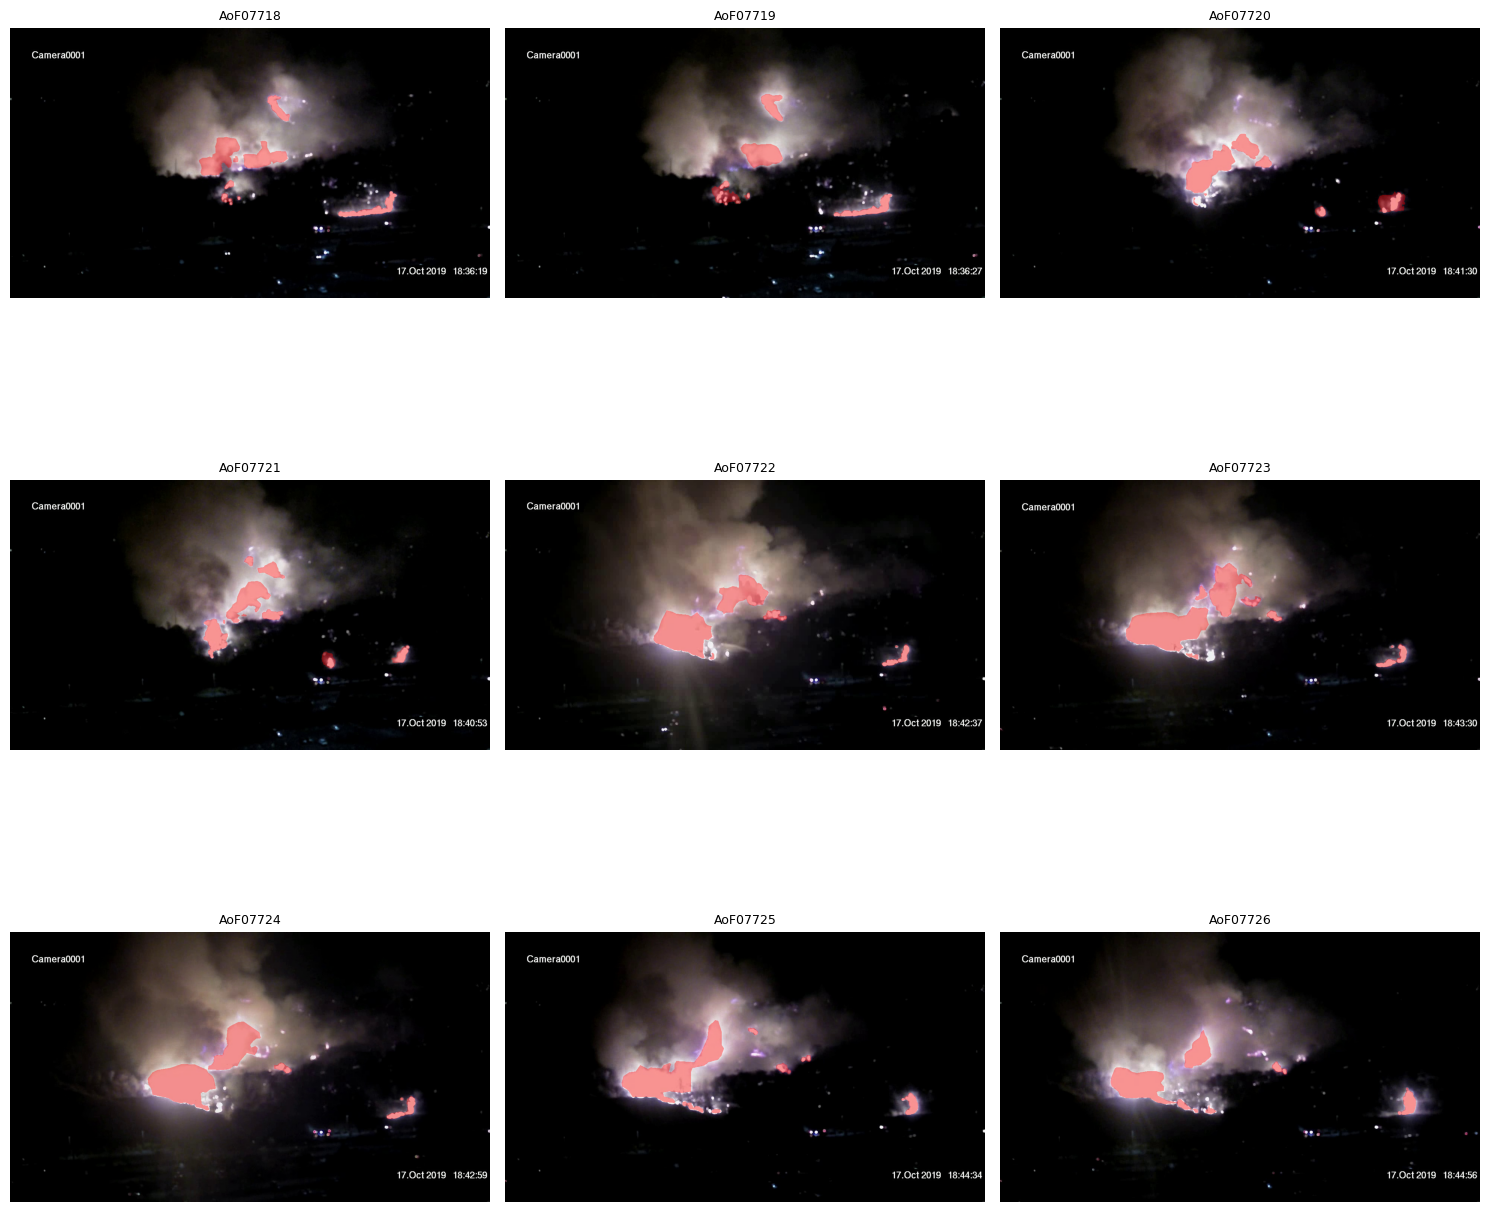

In [6]:
from verify_sam_masks import visualize_samples

visualize_samples(
    "/content/dfire_yolo_seg",
    n_samples=9
)

### 5. Mount Google Drive and process the full dataset

In [7]:
from google.colab import drive

drive.mount('/content/drive')

output_dir = "/content/drive/MyDrive/dfire_yolo_seg"

Mounted at /content/drive


In [8]:
from dfire_sam_to_yolo_seg import load_sam_model, process_dfire_dataset

predictor = load_sam_model(
    checkpoint_path="/content/sam_vit_b_01ec64.pth"
)

process_dfire_dataset(
    dfire_dir=dfire_path,
    output_dir=output_dir,
    predictor=predictor,
    max_images=None,
)

### 6. Download the Roboflow dataset

In [ ]:
!pip install -q roboflow

from roboflow import Roboflow

rf = Roboflow(api_key='ROBOFLOW_API_KEY')

project = rf.workspace("manuela-mayorga-rojas").project("fire-and-smoke-segmentation-3zmty")

dataset = project.version(1).download("yolov8")

print(dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-Segmentation-1 in yolov8:: 100%|██████████| 407/407 [00:00<00:00, 8158.06it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
/content/Fire-and-Smoke-Segmentation-1


### 7. Combine datasets

In [13]:
!cp -r /content/drive/MyDrive/dfire_yolo_seg /content/dfire_yolo_seg_local

In [14]:
!rm -rf /content/wildfire_dataset_v2

In [15]:
from combine_datasets import combine_datasets

combine_datasets(
    roboflow_dir="/content/Fire-and-Smoke-Segmentation-1",
    dfire_sam_dir="/content/dfire_yolo_seg_local",
    output_dir="/content/wildfire_dataset_v2",
)

In [16]:
!cp -r /content/wildfire_dataset_v2 /content/drive/MyDrive/wildfire_dataset_v2

In [19]:
import os

output_dir = "/content/wildfire_dataset_v2"

for split in ["train", "valid", "test"]:
    images_path = f"{output_dir}/{split}/images"
    labels_path = f"{output_dir}/{split}/labels"
    n_images = len(os.listdir(images_path)) if os.path.exists(images_path) else 0
    n_labels = len(os.listdir(labels_path)) if os.path.exists(labels_path) else 0
    print(f"{split}: {n_images} images | {n_labels} labels")

train: 4216 images | 4216 labels
valid: 1204 images | 1204 labels
test: 603 images | 603 labels


In [20]:
data_yaml_path = f"{output_dir}/data.yaml"
print(f"data.yaml exists?: {os.path.exists(data_yaml_path)}")

if os.path.exists(data_yaml_path):
    with open(data_yaml_path) as f:
        print(f.read())

data.yaml exists?: True
train: /content/wildfire_dataset_v2/train/images
val: /content/wildfire_dataset_v2/valid/images
test: /content/wildfire_dataset_v2/test/images
nc: 1
names: ['fire']



### 8. Train the model

In [21]:
from train_model import verify_environment, train_model, validate_model

verify_environment()

model = train_model(
    data_yaml="/content/drive/MyDrive/wildfire_dataset_v2/data.yaml",
    epochs=60,
    batch=48,
    cache="ram",
    experiment_name="yolo26n_seg_v2_combined",
)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/wildfire_dataset_v2/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_seg_v2_combined, nbs=64, nms=False, opset=None, o

### 9. Run inference only (upload new test images)

In [22]:
!pip install -q ultralytics roboflow

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [23]:
from google.colab import files
import os

os.makedirs('/content/test_images', exist_ok=True)

uploaded = files.upload()

for filename in uploaded:
    os.rename(filename, f'/content/test_images/{filename}')

Saving image1.jpg to image1.jpg
Saving image2.jpg to image2.jpg
Saving image3.jpg to image3.jpg
Saving image4.jpg to image4.jpg
Saving image5.jpg to image5.jpg
Saving image6.jpg to image6.jpg
Saving image7.jpg to image7.jpg
Saving image8.jpg to image8.jpg
Saving image9.jpg to image9.jpg
Saving image10.jpg to image10.jpg
Saving image11.jpg to image11.jpg
Saving image12.jpg to image12.jpg
Saving image13.jpg to image13.jpg
Saving image14.jpg to image14.jpg
Saving image15.jpg to image15.jpg
Saving image16.jpg to image16.jpg
Saving image17.jpg to image17.jpg
Saving image18.jpg to image18.jpg


In [24]:
from process_test_batch import process_batch

final_summary = process_batch(
    weights_path="/content/drive/MyDrive/wildfire_runs/yolo26n_seg_v2_combined/weights/best.pt",
    images_dir="/content/test_images",
    annotated_output_dir="/content/test_images_final",
    conf_threshold=0.15,
)

Image                    FP (%)    Level       Instances   
------------------------------------------------------------
image1.jpg               0.39      Low         2           
image10.jpg              0.41      Low         6           
image11.jpg              3.52      Medium      1           
image12.jpg              54.93     Critical    2           
image13.jpg              7.06      Medium      5           
image14.jpg              1.99      Low         11          
image15.jpg              5.58      Medium      2           
image16.jpg              23.1      High        5           
image17.jpg              0.93      Low         2           
image18.jpg              3.42      Medium      8           
image2.jpg               1.53      Low         6           
image3.jpg               11.46     High        3           
image4.jpg               4.26      Medium      7           
image5.jpg               0.42      Low         4           
image6.jpg               1.3       Low 

In [25]:
import shutil

shutil.make_archive(
    '/content/test_images_final',
    'zip',
    '/content/test_images_final'
)

from google.colab import files

files.download('/content/test_images_final.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 10. Results

In [26]:
!ls /content/drive/MyDrive/wildfire_runs/yolo26n_seg_v2_combined/

args.yaml			 MaskP_curve.png      train_batch4301.jpg
BoxF1_curve.png			 MaskPR_curve.png     train_batch4302.jpg
BoxP_curve.png			 MaskR_curve.png      val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	      val_batch0_pred.jpg
BoxR_curve.png			 results.png	      val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg     val_batch1_pred.jpg
confusion_matrix.png		 train_batch1.jpg     val_batch2_labels.jpg
labels.jpg			 train_batch2.jpg     val_batch2_pred.jpg
MaskF1_curve.png		 train_batch4300.jpg  weights


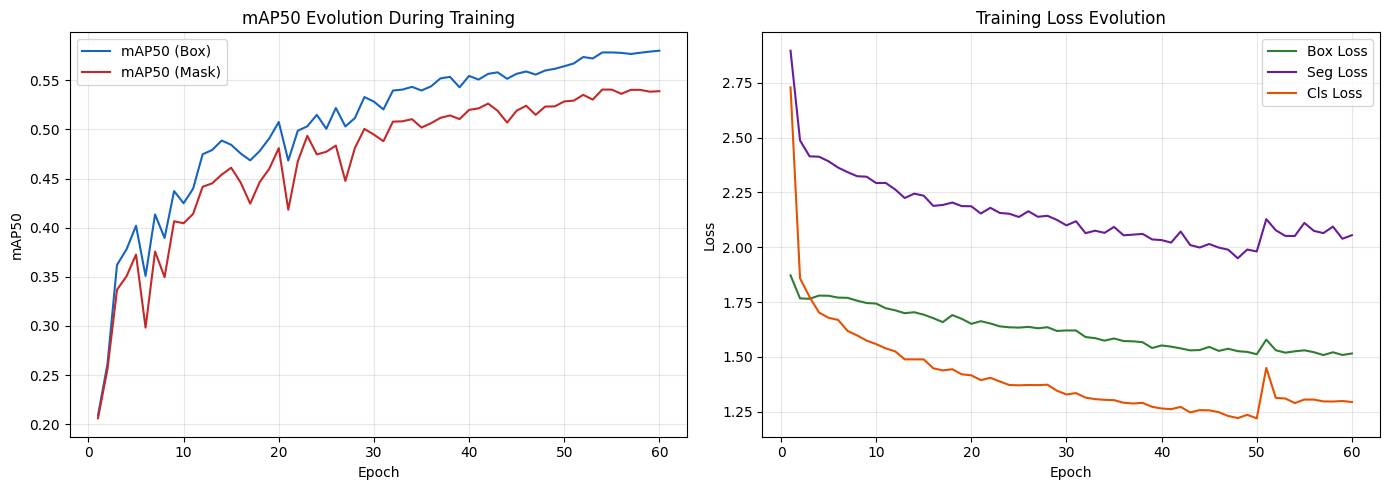

=== Final Training Metrics ===
train/box_loss                : 1.5155
train/seg_loss                : 2.0553
train/cls_loss                : 1.2942
train/dfl_loss                : 0.0050
train/sem_loss                : 0.8126
metrics/precision(B)          : 0.6188
metrics/recall(B)             : 0.5651
metrics/mAP50(B)              : 0.5800
metrics/mAP50-95(B)           : 0.3575
metrics/precision(M)          : 0.6172
metrics/recall(M)             : 0.5117
metrics/mAP50(M)              : 0.5388
metrics/mAP50-95(M)           : 0.2776
val/box_loss                  : 1.4895
val/seg_loss                  : 2.1672
val/cls_loss                  : 1.3373
val/dfl_loss                  : 0.0063
val/sem_loss                  : 0.0000


In [27]:
from generate_result_charts import (
    plot_training_evolution,
    plot_fire_percentage_per_image,
    print_final_metrics_table,
)

RUN_PATH = "/content/drive/MyDrive/wildfire_runs/yolo26n_seg_v2_combined"

plot_training_evolution(RUN_PATH)

print_final_metrics_table(RUN_PATH)

Image                    FP (%)    Level       Instances   
------------------------------------------------------------
image1.jpg               0.39      Low         2           
image10.jpg              0.41      Low         6           
image11.jpg              3.52      Medium      1           
image12.jpg              54.93     Critical    2           
image13.jpg              7.06      Medium      5           
image14.jpg              1.99      Low         11          
image15.jpg              5.58      Medium      2           
image16.jpg              23.1      High        5           
image17.jpg              0.93      Low         2           
image18.jpg              3.42      Medium      8           
image2.jpg               1.53      Low         6           
image3.jpg               11.46     High        3           
image4.jpg               4.26      Medium      7           
image5.jpg               0.42      Low         4           
image6.jpg               1.3       Low 

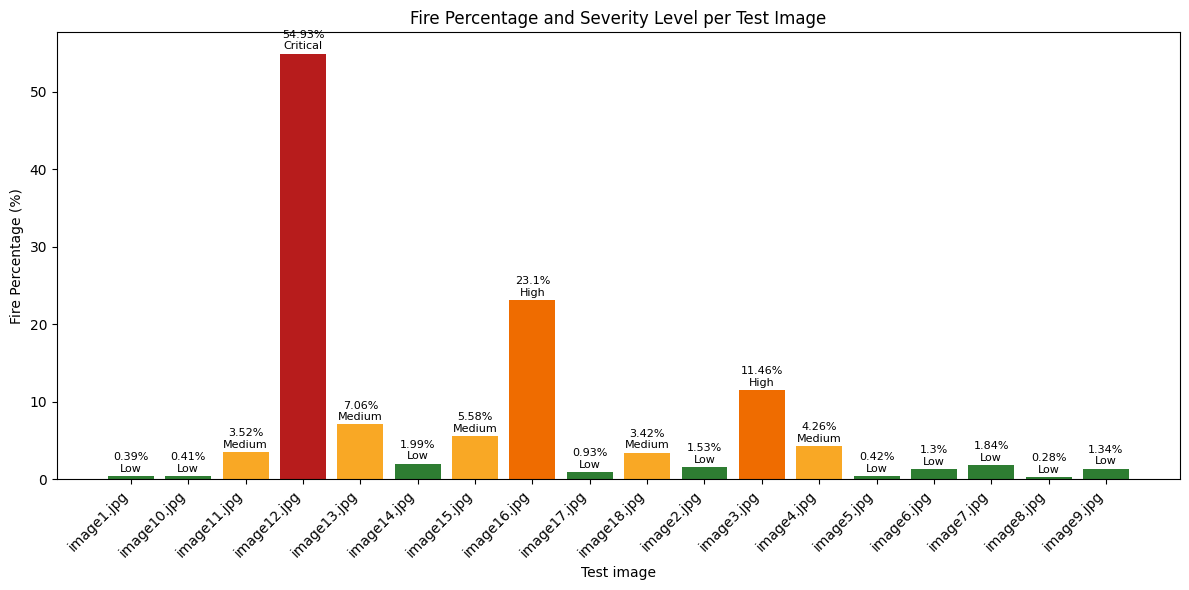

In [28]:
from process_test_batch import process_batch

summary = process_batch(
    weights_path=f"{RUN_PATH}/weights/best.pt",
    images_dir="/content/test_images",
    annotated_output_dir="/content/test_images_final",
    conf_threshold=0.15,
)

plot_fire_percentage_per_image(summary)

In [29]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/wildfire_runs/yolo26n_seg_v2_combined/weights/best.pt"
)

test_metrics = model.val(
    data="/content/drive/MyDrive/wildfire_dataset_v2/data.yaml",
    split="test",
)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1750.6±685.9 MB/s, size: 75.1 KB)
val: Scanning /content/wildfire_dataset_v2/test/labels... 603 images, 1 backgrounds, 14 corrupt: 100% ━━━━━━━━━━━━ 603/603 1.3Kit/s 0.5s
val: /content/wildfire_dataset_v2/test/images/rf_flare_0014_jpg.rf.20132c434393ee29e5f01965c75196be.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/wildfire_dataset_v2/test/images/rf_flare_0029_jpg.rf.63f15c726eb85c5f54fdcb285b35a73d.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/wildfire_dataset_v2/test/images/rf_flare_0058_jpg.rf.fa230642bb4dd426d5c8f473546ee287.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possibl

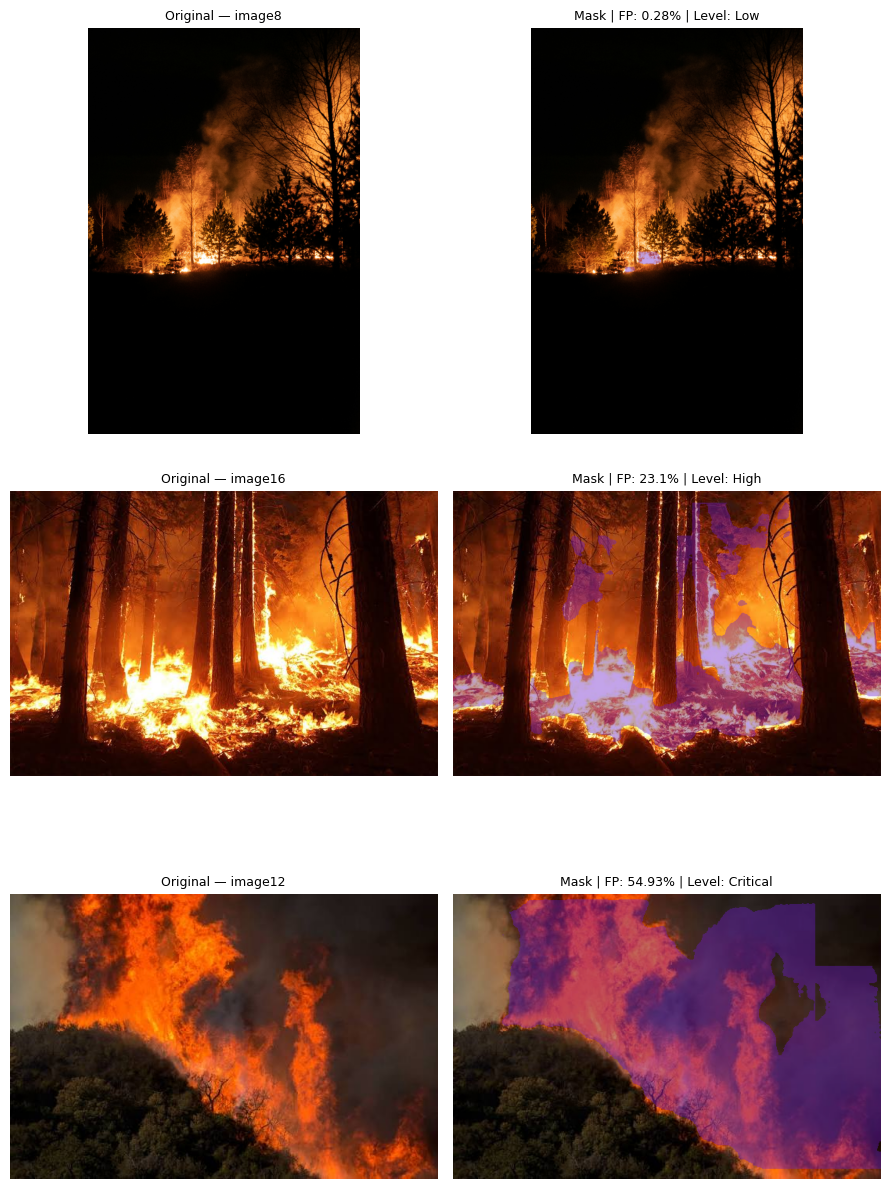

In [30]:
from generate_result_charts import plot_qualitative_sequence, plot_severity_distribution

# Qualitative sequence figure: pick 3 of your 18 test images
# (ideally one Low, one Medium/High, one Critical -- e.g. image8, image16, image12)

plot_qualitative_sequence(
    weights_path="/content/drive/MyDrive/wildfire_runs/yolo26n_seg_v2_combined/weights/best.pt",
    image_paths=[
        "/content/test_images/image8.jpg",
        "/content/test_images/image16.jpg",
        "/content/test_images/image12.jpg",
    ],
    conf_threshold=0.15,
)

Image                    FP (%)    Level       Instances   
------------------------------------------------------------
image1.jpg               0.39      Low         2           
image10.jpg              0.41      Low         6           
image11.jpg              3.52      Medium      1           
image12.jpg              54.93     Critical    2           
image13.jpg              7.06      Medium      5           
image14.jpg              1.99      Low         11          
image15.jpg              5.58      Medium      2           
image16.jpg              23.1      High        5           
image17.jpg              0.93      Low         2           
image18.jpg              3.42      Medium      8           
image2.jpg               1.53      Low         6           
image3.jpg               11.46     High        3           
image4.jpg               4.26      Medium      7           
image5.jpg               0.42      Low         4           
image6.jpg               1.3       Low 

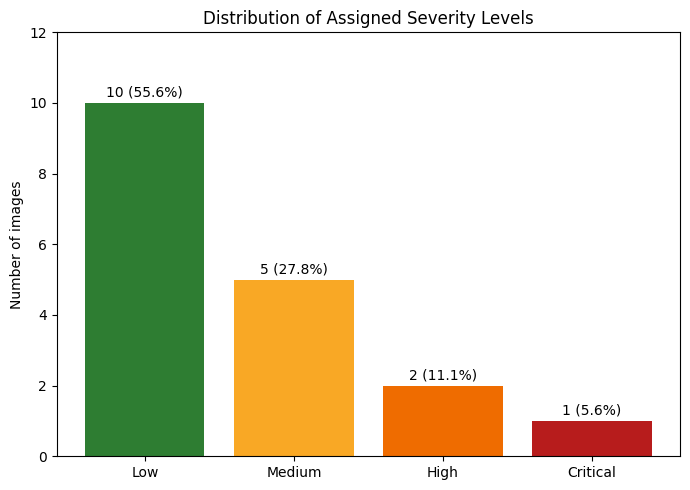

In [31]:
from process_test_batch import process_batch

summary = process_batch(
    weights_path="/content/drive/MyDrive/wildfire_runs/yolo26n_seg_v2_combined/weights/best.pt",
    images_dir="/content/test_images",
    annotated_output_dir="/content/test_images_final",
    conf_threshold=0.15,
)

plot_severity_distribution(summary)

Using folder: val


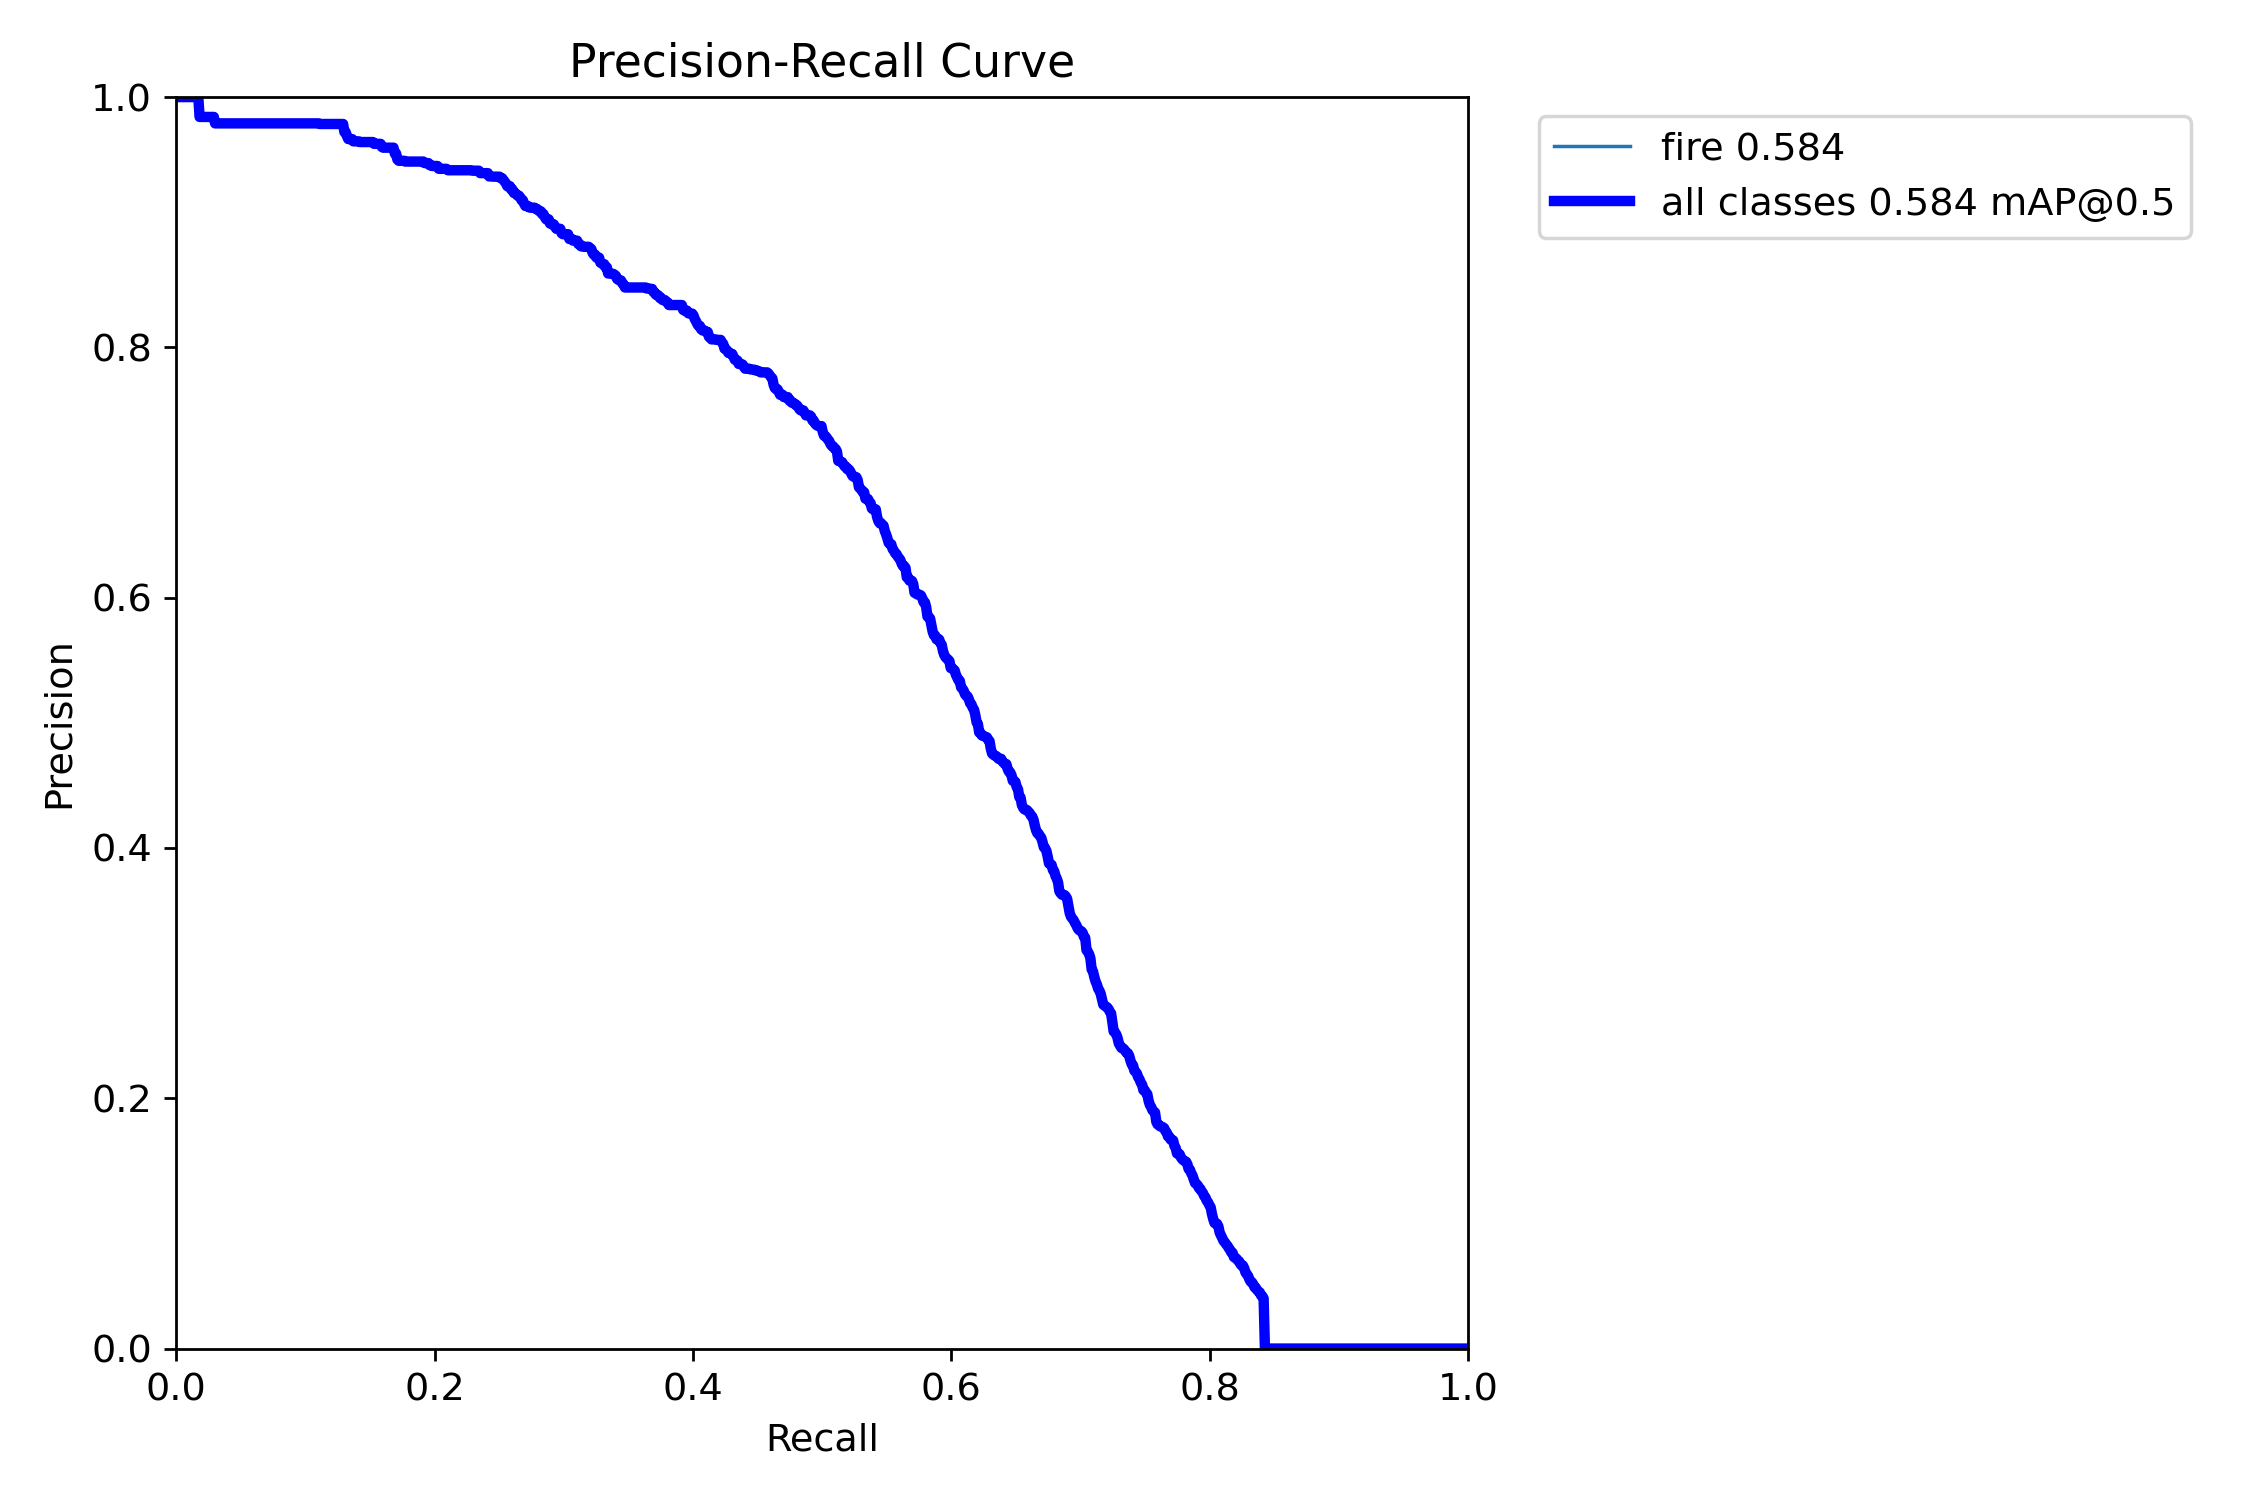

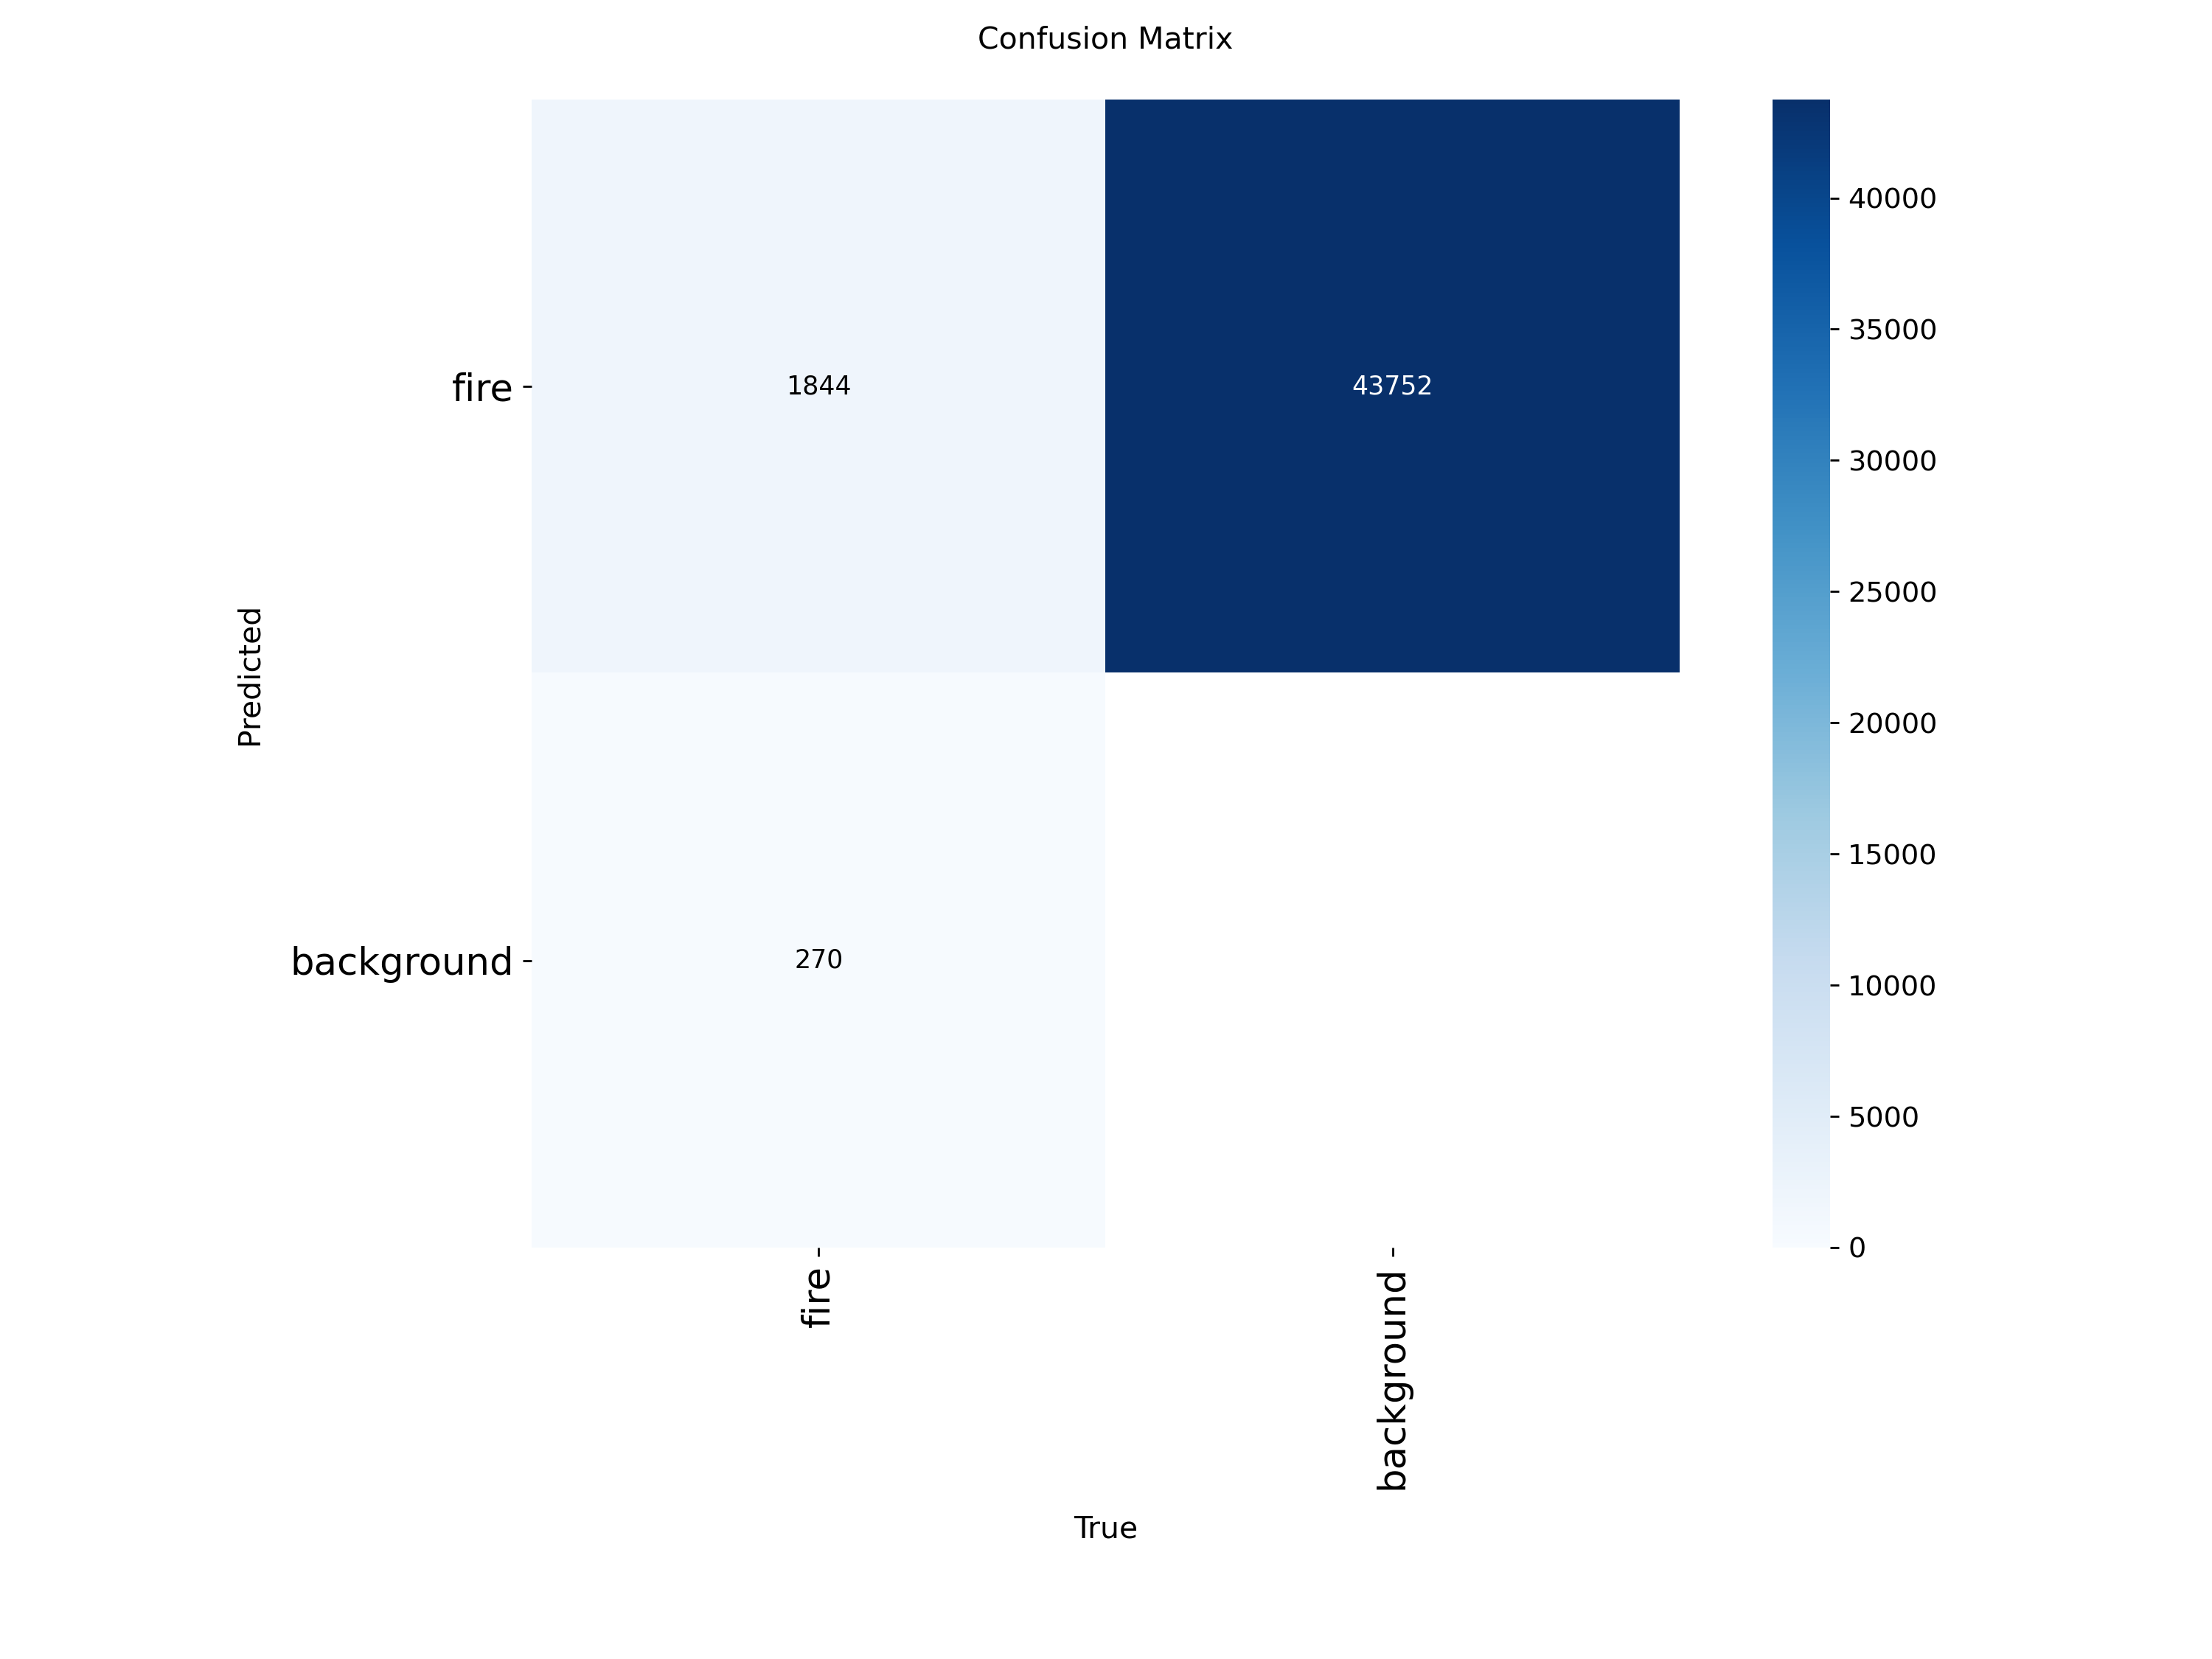

In [32]:
from IPython.display import Image, display
import os

folders = sorted(
    [d for d in os.listdir("/content/runs/segment") if d.startswith("val")],
    key=lambda d: os.path.getmtime(f"/content/runs/segment/{d}")
)

latest_folder = folders[-1]

print(f"Using folder: {latest_folder}")

display(Image(f"/content/runs/segment/{latest_folder}/MaskPR_curve.png"))

display(Image(f"/content/runs/segment/{latest_folder}/confusion_matrix.png"))